In [ ]:
import os
import pickle
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import mobilenet_v2, efficientnet_b0, resnet50
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from collections import Counter
from torch import nn
from torch.nn import functional as F
import time
import logging
import kagglehub
import csv
import matplotlib.pyplot as plt
from datetime import datetime
import albumentations as A
from math import ceil

CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SPLIT_FILE = os.path.join(CHECKPOINT_DIR, 'split_indices.pkl')

class ModelOutput:
    def __init__(self, logits, attentions=None):
        self.logits = logits
        self.attentions = attentions

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, gamma, reduction='mean'):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, samples_per_cls):
        num_classes = logits.size(1)
        effective_num = 1.0 - torch.pow(self.beta, samples_per_cls)
        effective_num = torch.clamp(effective_num, min=1e-6)
        weights = (1.0 - self.beta) / (effective_num)
        weights = weights / weights.sum() * logits.size(1)
        weights = torch.clamp(weights, min=0.0)
        weights = weights.to(logits.device)
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        log_probs = torch.clamp(F.log_softmax(logits, dim=1), min=-20.0, max=0.0)
        probs = torch.exp(log_probs)
        focal_weight = torch.pow(1 - probs, self.gamma)
        cb_loss = -weights.unsqueeze(0) * focal_weight * targets_one_hot * log_probs
        loss = cb_loss.sum(dim=1)

        return loss.mean() if self.reduction == 'mean' else loss.sum()

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        confidence = 1.0 - self.smoothing
        log_probs = F.log_softmax(logits, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=targets.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

class Caltech256Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "label": torch.tensor(label, dtype=torch.long)}

def load_dataset(root_dir, transform):
    return Caltech256Dataset(root_dir=root_dir, transform=transform)

def split_dataset(dataset, test_size=0.3, val_size=0.5, random_state=11):
    labels = dataset.labels
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))
    temp_labels = [labels[i] for i in temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    val_idx, test_idx = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]
    return train_idx, val_idx, test_idx

def get_transform(aug_params):
    albu_transforms = A.Compose([
        A.Resize(256, 256),
        A.CenterCrop(aug_params['center_crop_size'], aug_params['center_crop_size']),
        A.HorizontalFlip(p=aug_params['horizontal_flip']),
        A.Rotate(limit=aug_params['rotation'], p=0.5),
        A.ColorJitter(
            brightness=aug_params['brightness'],
            contrast=aug_params['contrast'],
            saturation=aug_params['saturation'],
            hue=aug_params['hue'],
            p=0.5
        ),
        A.Affine(
            rotate=aug_params['affine_degrees'],
            translate_percent=aug_params['affine_translate'],
            shear=aug_params['affine_shear'],
            p=0.5
        ),
        A.GaussianBlur(
            kernel_size=aug_params['gaussian_blur_kernel'],
            sigma=aug_params['gaussian_blur_sigma'],
            p=0.5
        ),
    ])

    torch_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ,
        transforms.RandomErasing(p=aug_params['random_erasing'])
    ])

    def combined_transform(image):
        image = albu_transforms(image=np.array(image))['image']
        image = torch_transforms(image)
        return image

    return combined_transform

def get_sampler(dataset, train_idx):
    train_labels = [dataset.labels[i] for i in train_idx]
    train_class_counts = Counter(train_labels)
    sample_weights = [1.0 / train_class_counts[label] for label in train_labels]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

def get_model(cnn_model_name, vit_model_name, num_classes, freeze_cnn_layers=0, freeze_vit_layers=0, device='cuda', vit_local_path='./local_model/vit-base-patch16-224-in21k'):
    if cnn_model_name == 'mobilenet_v2':
        cnn = mobilenet_v2(pretrained=True)
        cnn = nn.Sequential(*list(cnn.features))
        feature_dim = 1280
    elif cnn_model_name == 'efficientnet_b0':
        cnn = efficientnet_b0(pretrained=True)
        cnn = cnn.features
        feature_dim = 1280
    elif cnn_model_name == 'resnet50':
        full_model = resnet50(pretrained=True)
        cnn = nn.Sequential(*list(full_model.children())[:-2])
        feature_dim = 2048
    else:
        raise ValueError("Unsupported CNN model")

    config_vit = ViTConfig(
        hidden_size=1024,
        num_hidden_layers=24,
        num_attention_heads=16,
        intermediate_size=4096,
        image_size=224,
        patch_size=16,
        num_channels=3,
        output_attentions=True,
        attn_implementation="eager" 
    )
    vit = ViTModel(config_vit)
    vit.config.hidden_dropout_prob = 0.1
    vit.config.attention_probs_dropout_prob = 0.1
    hidden_size = vit.config.hidden_size

    num_patches = 49
    positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
    nn.init.normal_(positional_embeddings, std=0.02)

    projection = nn.Linear(feature_dim, hidden_size)
    classifier = nn.Linear(hidden_size, num_classes)

    class HybridModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = cnn
            self.dropout_cnn = nn.Dropout(0.1)
            self.projection = projection
            self.dropout_proj = nn.Dropout(0.1)
            self.vit = vit
            self.positional_embeddings = positional_embeddings
            self.dropout = nn.Dropout(0.1)
            self.ln = nn.LayerNorm(hidden_size)
            self.classifier = classifier
            self.feature_dim = feature_dim
        def adjust_dropout(self, epoch, max_epochs, min_dropout=0.1, max_dropout=0.5):
            dropout_rate = min_dropout + (max_dropout - min_dropout) * (epoch / max_epochs)
            self.dropout_cnn.p = dropout_rate
            self.dropout_proj.p = dropout_rate
            self.dropout.p = dropout_rate
        def forward(self, pixel_values):
            features = self.cnn(pixel_values)
            features = self.dropout_cnn(features)
            batch_size = features.size(0)
            if features.size(2) != 7 or features.size(3) != 7:
                raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
            features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
            projected_features = self.projection(features)
            projected_features = self.dropout_proj(projected_features)
            cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
            embeddings = torch.cat([cls_token, projected_features], dim=1)
            embeddings = embeddings + self.positional_embeddings
            encoder_outputs = self.vit.encoder(embeddings, output_attentions=True)
            cls_output = encoder_outputs.last_hidden_state[:, 0, :]
            cls_output = self.ln(cls_output)
            cls_output = self.dropout(cls_output)
            logits = self.classifier(cls_output)
            attentions = encoder_outputs.attentions
            return ModelOutput(logits=logits, attentions=attentions)

    model = HybridModel().to(device)

    if freeze_cnn_layers > 0:
        for i in range(min(freeze_cnn_layers, len(cnn))):
            for param in cnn[i].parameters():
                param.requires_grad = False
        print(f"Froze the first {min(freeze_cnn_layers, len(cnn))} layers of the CNN.")

    if freeze_vit_layers > 0:
        num_vit_layers = len(vit.encoder.layer)
        freeze_vit_layers = min(freeze_vit_layers, num_vit_layers)
        for i in range(freeze_vit_layers):
            for param in vit.encoder.layer[i].parameters():
                param.requires_grad = False
        print(f"Froze the first {freeze_vit_layers} layers of the ViT encoder.")

    return model

def grid_mix(model, pixel_values, labels, grid_size=(3, 3), device='cuda'):
    """
    Performs attention-based CutMix with grid_size as the number of divisions.
    """
    with torch.no_grad():
        outputs = model(pixel_values)
        attentions = outputs.attentions
    
    layer_attentions = [attn[:, :, 0, 1:].mean(dim=1) for attn in attentions]
    avg_attention = torch.stack(layer_attentions, dim=0).mean(dim=0)  #(batch_size, 49)
    attention_maps = avg_attention.view(-1, 7, 7)  #(batch_size, 7, 7)
    
    grid_height, grid_width = grid_size
    window_height = ceil(7 / grid_height)  #patches per region vertically
    window_width = ceil(7 / grid_width)    #patches per region horizontally
    
    stride_h = max(1, 7 // grid_height)
    stride_w = max(1, 7 // grid_width)
    
    window_averages = F.avg_pool2d(
        attention_maps.unsqueeze(1),  # (batch_size, 1, 7, 7)
        kernel_size=(window_height, window_width),
        stride=(stride_h, stride_w)
    ).squeeze(1)  # (batch_size, output_h, output_w)
    
    batch_size = pixel_values.size(0)
    index = torch.randperm(batch_size).to(device)
    
    flat_indices_min = window_averages.view(batch_size, -1).argmin(dim=1)
    p_min = flat_indices_min // window_averages.size(2)  #row indices
    q_min = flat_indices_min % window_averages.size(2)  #column indices
    
    flat_indices_max = window_averages[index].view(batch_size, -1).argmax(dim=1)
    p_max = flat_indices_max // window_averages.size(2)
    q_max = flat_indices_max % window_averages.size(2)
    
    patch_size = 224 // 7 
    window_pixels_h = window_height * patch_size
    window_pixels_w = window_width * patch_size
    
    mixed_pixel_values = pixel_values.clone()
    
    for i in range(batch_size):
        dst_top = p_min[i] * stride_h * patch_size
        dst_bottom = dst_top + window_pixels_h
        dst_left = q_min[i] * stride_w * patch_size
        dst_right = dst_left + window_pixels_w
        
        src_top = p_max[i] * stride_h * patch_size
        src_bottom = src_top + window_pixels_h
        src_left = q_max[i] * stride_w * patch_size
        src_right = src_left + window_pixels_w
        
        dst_bottom = min(dst_bottom, 224)
        dst_right = min(dst_right, 224)
        src_bottom = min(src_bottom, 224)
        src_right = min(src_right, 224)
        
        mixed_pixel_values[i, :, dst_top:dst_bottom, dst_left:dst_right] = \
            pixel_values[index[i], :, src_top:src_bottom, src_left:src_right]
    
    total_area = 224 * 224
    replaced_area = window_pixels_h * window_pixels_w
    lam = 1 - (replaced_area / total_area)
    
    labels_a = labels
    labels_b = labels[index]
    
    return mixed_pixel_values, labels_a, labels_b, lam

def unfreeze_cnn_layers(model, epoch, T_0=5, T_mult=2, max_layers=9):
    restart_points = [0]
    t = T_0
    while restart_points[-1] + t <= epoch:
        restart_points.append(restart_points[-1] + t)
        t *= T_mult
    num_restarts = len(restart_points) - 1
    layers_to_unfreeze = min(max_layers, 1 + num_restarts * 2)
    unfrozen_layers = sum(1 for layer in model.cnn if any(param.requires_grad for param in layer.parameters()))
    if layers_to_unfreeze > unfrozen_layers:
        for i in range(unfrozen_layers, layers_to_unfreeze):
            for param in model.cnn[i].parameters():
                param.requires_grad = True
        print(f"[Epoch {epoch}] Unfroze {layers_to_unfreeze} of {max_layers} CNN layers after {num_restarts} restarts.")
    return layers_to_unfreeze

def unfreeze_vit_layers(model, epoch, T_0=5, T_mult=2, max_layers=24, layers_per_restart=6):
    restart_points = [0]
    t = T_0
    while restart_points[-1] + t <= epoch:
        restart_points.append(restart_points[-1] + t)
        t *= T_mult
    num_restarts = len(restart_points) - 1
    layers_to_unfreeze = min(max_layers, 1 + num_restarts * layers_per_restart)
    vit_layers = model.vit.encoder.layer
    unfrozen_layers = sum(
        any(param.requires_grad for param in vit_layers[i].parameters())
        for i in range(len(vit_layers))
    )
    if layers_to_unfreeze > unfrozen_layers:
        for i in range(unfrozen_layers, layers_to_unfreeze):
            for param in vit_layers[i].parameters():
                param.requires_grad = True
        print(f"[Epoch {epoch}] Unfroze {layers_to_unfreeze} of {max_layers} ViT layers after {num_restarts} restarts.")
    
    return layers_to_unfreeze

def get_optimizer(model, cnn_lr, vit_lr, weight_decay):
    vit_params = list(model.vit.parameters()) + [model.positional_embeddings]
    cnn_params = list(model.cnn.parameters()) + \
                 list(model.projection.parameters()) + \
                 list(model.classifier.parameters()) + \
                 list(model.ln.parameters()) + \
                 list(model.dropout.parameters()) + \
                 list(model.dropout_proj.parameters()) + \
                 list(model.dropout_cnn.parameters())
    
    vit_param_ids = set(id(p) for p in vit_params)
    cnn_params = [p for p in cnn_params if id(p) not in vit_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': cnn_params, 'lr': cnn_lr},
        {'params': vit_params, 'lr': vit_lr}
    ], weight_decay=weight_decay, betas=(0.9, 0.95))
    
    return optimizer

def get_scheduler(optimizer, override_sch):
    if(not override_sch):
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2,min_lr=1e-7)
    else:
        return torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)
    
def get_loss_function(loss_type, **kwargs):
    if loss_type == 'focal':
        return FocalLoss(gamma=kwargs.get('gamma', 2.0))
    elif loss_type == 'class_balanced':
        return ClassBalancedLoss(beta=kwargs.get('beta', 0.9), gamma=kwargs.get('gamma', 2.0))
    elif loss_type == 'label_smoothing':
        return LabelSmoothingCrossEntropy(smoothing=kwargs.get('smoothing', 0.1))
    else:
        raise ValueError("Unsupported loss type")

def evaluate_model(model, data_loader, criterion, device, samples_per_cls=None):
    model.eval()
    total_loss = 0
    preds = []
    true_labels = []
    eval_criterion = nn.CrossEntropyLoss().to(device)
    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values)
                logits = outputs.logits
                loss = eval_criterion(logits, labels_batch)
            total_loss += loss.item()
            preds.extend(logits.argmax(dim=-1).cpu().numpy())
            true_labels.extend(labels_batch.cpu().numpy())
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, preds)
    macro_f1 = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)[2]
    return avg_loss, accuracy, macro_f1

def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def augmentation_prob_schedule(epoch, noaugments):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        prob = 0.1 + (0.3 * (epoch / warmup_epochs))
    elif(noaugments):
        prob=0
    else:
        #prob = 0.3
        prob = 0.4
    print(f"Augmentation Probability: {prob:.3f}")
    return prob

def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, num_epochs, patience, device, samples_per_cls=None, augmentation_prob=0.1, alphac=0.1, alpham=0.1, start_epoch=0, checkpoint_dir=CHECKPOINT_DIR,override_schl=False,unfreeze=True,noaugments=False):
    print(f"Using checkpoint directory at {checkpoint_dir}")

    log_file_path = os.path.join(checkpoint_dir, 'training_log.txt')
    logging.basicConfig(filename=log_file_path, level=logging.INFO, format='%(message)s', filemode='a')
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    if start_epoch == 0:
        logging.info(f"\n----- New Training Session Started at {current_time} -----")
    else:
        logging.info(f"\n----- Training Resumed at {current_time} from epoch {start_epoch} -----")

    data_file_path = os.path.join(checkpoint_dir, 'loss_data.csv')
    if start_epoch == 0:
        with open(data_file_path, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Epoch', 'Train Loss', 'Val Loss', 'Val Accuracy'])
    elif not os.path.exists(data_file_path):
        with open(data_file_path, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Epoch', 'Train Loss', 'Val Loss', 'Val Accuracy'])

    best_val_loss = float('inf')
    early_stop_counter = 0
    scaler = torch.amp.GradScaler('cuda')
    overall_start_time = time.time()
    freeze_cnn_layers = 0 
    freeze_vit_layers = 0
    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        accum_steps = 256 // 32 
        model.adjust_dropout(epoch, num_epochs)
        augmentation_prob = augmentation_prob_schedule(epoch, noaugments)


        if(unfreeze):
            freeze_cnn_layers=unfreeze_cnn_layers(model, epoch, T_0=5, T_mult=2, max_layers=9)
            freeze_vit_layers=unfreeze_vit_layers(model, epoch, T_0=5, T_mult=2, max_layers=24)
        for i, batch in enumerate(train_loader):
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            #optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                if np.random.rand() < augmentation_prob:
                    if np.random.rand() < 0.5:
                        pixel_values, labels_a, labels_b, lam = mixup_data(pixel_values, labels_batch, alpha=alpham)
                    else:
                        pixel_values, labels_a, labels_b, lam = grid_mix(
                            model, pixel_values, labels_batch, grid_size=config['grid_size'], device=device
                        )
                    outputs = model(pixel_values)
                    logits = outputs.logits
                    if isinstance(criterion, ClassBalancedLoss):
                        loss = lam * criterion(logits, labels_a, samples_per_cls) + (1 - lam) * criterion(logits, labels_b, samples_per_cls,)
                    else:
                        loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
                else:
                    outputs = model(pixel_values)
                    logits = outputs.logits
                    loss = criterion(logits, labels_batch, samples_per_cls) if isinstance(criterion, ClassBalancedLoss) else criterion(logits, labels_batch)
            scaler.scale(loss).backward()
            if (i + 1) % accum_steps == 0 or (i + 1 == len(train_loader)):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            total_loss += loss.item()
            if (i + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Batch {i+1}/{len(train_loader)}, Batch Loss: {loss.item():.4f}, CNN Learning Rate = {optimizer.param_groups[0]['lr']:.4e} , Vit Learning Rate = {optimizer.param_groups[1]['lr']:.4e}")

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        val_loss, val_accuracy, val_macro_f1 = evaluate_model(model, val_loader, criterion, device, samples_per_cls)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Macro F1: {val_macro_f1:.4f}")

        logging.info(f"Epoch: {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")
        with open(data_file_path, 'a', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow([epoch + 1, avg_train_loss, val_loss, val_accuracy])

        checkpoint_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

        epoch_end_time = time.time()
        epoch_time = epoch_end_time - epoch_start_time
        total_time = epoch_end_time - overall_start_time
        print(f"Epoch {epoch+1} completed in {epoch_time/60.0:.2f} minutes. Total time elapsed: {total_time/60.0:.2f} minutes.")
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step(epoch + 1)
        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            early_stop_counter = 0
            print(f"Early stopping counter: {early_stop_counter}, Saving Best Loss: {best_val_loss:.4f}.")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss': val_loss,
                'train_loss': avg_train_loss
            }, os.path.join(checkpoint_dir, 'best_vit_caltech256.pth'))
        else:



            early_stop_counter += 1
            print(f"Early stopping counter: {early_stop_counter}, Best Loss: {best_val_loss:.4f}.")
            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

def load_checkpoint(model, optimizer, scheduler, checkpoint_path, device, new_lr=None,overrideSchl=False):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    
    if(not overrideSchl):
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if new_lr is not None:
        for param_group in optimizer.param_groups:
            old_lr = param_group['lr']
            param_group['lr'] = new_lr
            print(f"Overridden optimizer LR: {old_lr:.6e} -> {new_lr:.6e}")
        if hasattr(scheduler, 'base_lrs'):
            old_base_lrs = scheduler.base_lrs
            scheduler.base_lrs = [new_lr for _ in scheduler.base_lrs]
            print(f"Updated scheduler base_lrs: {[f'{l:.6e}' for l in old_base_lrs]} -> {[f'{new_lr:.6e}' for _ in old_base_lrs]}")
    start_epoch = checkpoint['epoch']
    print(f"Loaded checkpoint from {checkpoint_path}, resuming from epoch {start_epoch}")
    return start_epoch

def plot_loss_curves(checkpoint_dir=CHECKPOINT_DIR):
    data_file_path = os.path.join(checkpoint_dir, 'loss_data.csv')
    epochs = []
    train_losses = []
    val_losses = []
    val_accuracies = []
    try:
        with open(data_file_path, 'r') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                epochs.append(int(row['Epoch']))
                train_losses.append(float(row['Train Loss']))
                val_losses.append(float(row['Val Loss']))
                val_accuracies.append(float(row['Val Accuracy']))
    except FileNotFoundError:
        print(f"Loss data file not found at {data_file_path}. Please ensure training has run at least once.")
        return

    if not epochs:
        print("No data found in the loss data file to plot.")
        return

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plot_path = os.path.join(checkpoint_dir, 'loss_accuracy_curves.png')
    plt.savefig(plot_path)
    print(f"Loss and accuracy curves plot saved to {plot_path}")
    plt.show()

def main(config):
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. Ensure NVIDIA drivers and CUDA toolkit are installed.")
    print(f"CUDA is available! Found {torch.cuda.device_count()} GPU(s).")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    config['device'] = torch.device("cuda:0")

    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    torch.backends.cudnn.deterministic = True

    transform = get_transform(config['augmentation_params'])
    dataset = load_dataset(config['dataset_path'], transform)

    if os.path.exists(SPLIT_FILE):
        with open(SPLIT_FILE, 'rb') as f:
            train_idx, val_idx, test_idx = pickle.load(f)
        print(f"Loaded split indices from {SPLIT_FILE}")
    else:
        train_idx, val_idx, test_idx = split_dataset(dataset, config['test_size'], config['val_size'], config['seed'])
        with open(SPLIT_FILE, 'wb') as f:
            pickle.dump((train_idx, val_idx, test_idx), f)
        print(f"Split indices saved to {SPLIT_FILE}")

    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)

    sampler = get_sampler(dataset, train_idx)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], sampler=sampler, num_workers=config['num_workers'], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'], pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'], pin_memory=True)

    model = get_model(config['cnn_model_name'], config['model_name'], config['num_classes'],
                      config['freeze_cnn_layers'], config['freeze_vit_layers'], config['device'],
                      config['vit_local_path'])
    #optimizer = get_optimizer(model, config['lr'], config['weight_decay'])
    optimizer = get_optimizer(model, cnn_lr=(config['lr']*10), vit_lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = get_scheduler(optimizer, config['dynamic_unfreeze'])

    if config['loss_type'] == 'class_balanced':
        train_labels = [dataset.labels[i] for i in train_idx]
        samples_per_cls = torch.zeros(config['num_classes'])
        for i, count in Counter(train_labels).items():
            samples_per_cls[i] = count
        criterion = get_loss_function(config['loss_type'], beta=config['beta'], gamma=config['gamma'])
    elif config['loss_type'] == 'label_smoothing':
        criterion = get_loss_function(config['loss_type'], smoothing=config['smoothing'])
        samples_per_cls = None
    else:
        criterion = get_loss_function(config['loss_type'], gamma=config['gamma'])
        samples_per_cls = None

    start_epoch = 0
    if config.get('load_checkpoint', False):
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pth')
        if os.path.exists(checkpoint_path):
            start_epoch = load_checkpoint(model, optimizer, scheduler, checkpoint_path, config['device'], new_lr=config['lr'] if config['override_lr'] else None,overrideSchl=config['override_sch'])
        else:
            print(f"Checkpoint file {checkpoint_path} not found. Starting from scratch.")

    train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, config['num_epochs'],
                config['patience'], config['device'], samples_per_cls, config['augmentation_prob'], config['cutmix_alpha'], config['mixup_alpha'], start_epoch, checkpoint_dir=CHECKPOINT_DIR,override_schl=config['override_sch'],unfreeze=config['dynamic_unfreeze'],noaugments=config['noaugments'])

    best_checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_vit_caltech256.pth')
    checkpoint = torch.load(best_checkpoint_path, map_location=config['device'])
    model.load_state_dict(checkpoint['model_state_dict'])
    test_loss, test_accuracy, test_macro_f1 = evaluate_model(model, test_loader, criterion, config['device'], samples_per_cls)
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, Macro F1: {test_macro_f1:.4f}")

path = kagglehub.dataset_download('jessicali9530/caltech256')
# path2 unused
local_model_path = './local_model'
config = {
    'seed': 50,
    'model_name': "google/vit-large-patch16-224-in21k",
    'num_classes': 257,
    'dataset_path': os.path.join(path, "256_ObjectCategories"),
    'vit_local_path': local_model_path,
    'test_size': 0.3,
    'val_size': 0.5,
    'augmentation_params': {
        'center_crop_size': 224,
        'horizontal_flip': 0.2,
        'rotation': 15,
        'brightness': 0.2,
        'contrast': 0.2,
        'saturation': 0.2,
        'hue': 0.05,
        'random_erasing': 0.05,
        'affine_degrees': 10,
        'affine_translate': (0.1, 0.1),
        'affine_shear': 5,
        'gaussian_blur_kernel': 3,
        'gaussian_blur_sigma': (0.2, 0.5),
    },
    'mixup_alpha': 0.2,
    'cutmix_alpha': 0.5,
    'augmentation_prob': 0.1,
    'batch_size': 12,
    'num_workers': 0,
    'lr': 3e-5,
    'weight_decay': 1e-4,
    'T_max': True,
    'loss_type': 'class_balanced',
    'smoothing': 0.05,
    'beta': 0.7,
    'gamma': 1.0,
    'num_epochs': 200,
    'patience': 5,
    'device': torch.device("cuda:0"),
    'load_checkpoint': True,
    'freeze_cnn_layers': 9,
    'freeze_vit_layers': 24,
    'cnn_model_name': 'efficientnet_b0',
    'grid_size': (3, 3),
    'override_lr':False,
    'override_sch':False,
    'dynamic_unfreeze':True,
    'noaugments':False,
    'LR': True
}

if __name__ == "__main__":
    main(config)

d:\CONDA\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
def get_model2(cnn_model_name, vit_model_name, num_classes, freeze_cnn_layers=0, freeze_vit_layers=0, device='cuda', vit_local_path='./local_model/vit-base-patch16-224-in21k'):
    vit = ViTModel.from_pretrained(vit_model_name, output_attentions=True,attn_implementation="eager")
    hidden_size = vit.config.hidden_size
    vit.config.hidden_dropout_prob = 0.1
    vit.config.attention_probs_dropout_prob = 0.1
    classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_classes)
        )

    class ViTClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.vit = vit
            self.classifier = classifier
        def adjust_dropout(self, epoch, max_epochs, min_dropout=0.1, max_dropout=0.5):
            dropout_rate = min_dropout + (max_dropout - min_dropout) * (epoch / max_epochs)
            if isinstance(self.classifier[1], nn.Dropout):
                self.classifier[1].p = dropout_rate
        def forward(self, pixel_values):
            outputs = self.vit(pixel_values=pixel_values, output_attentions=True)
            cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token
            logits = self.classifier(cls_output)
            return ModelOutput(logits=logits, attentions=outputs.attentions)

    model = ViTClassifier().to(device)

    if freeze_vit_layers > 0:
        num_vit_layers = len(vit.encoder.layer)
        freeze_vit_layers = min(freeze_vit_layers, num_vit_layers)
        for i in range(freeze_vit_layers):
            for param in vit.encoder.layer[i].parameters():
                param.requires_grad = False
        print(f"Froze the first {freeze_vit_layers} layers of the ViT encoder.")

    return model
def get_optimizer2(model, vit_lr, weight_decay):
    return torch.optim.AdamW(model.parameters(),lr=vit_lr, weight_decay=weight_decay, betas=(0.9, 0.95))
def grid_mix2(model, pixel_values, labels, grid_size=(3, 3), device='cuda'):
    """
    Performs attention-based CutMix with grid_size as the number of divisions.
    """
    with torch.no_grad():
        outputs = model(pixel_values)
        attentions = outputs.attentions
    
    layer_attentions = [attn[:, :, 0, 1:].mean(dim=1) for attn in attentions]
    avg_attention = torch.stack(layer_attentions, dim=0).mean(dim=0) 
    attention_maps = avg_attention.view(-1, 7, 7)  
    
    grid_height, grid_width = grid_size
    window_height = ceil(7 / grid_height)  
    window_width = ceil(7 / grid_width)    
    
    stride_h = max(1, 7 // grid_height)
    stride_w = max(1, 7 // grid_width)
    
    window_averages = F.avg_pool2d(
        attention_maps.unsqueeze(1),  
        kernel_size=(window_height, window_width),
        stride=(stride_h, stride_w)
    ).squeeze(1)  
    
    batch_size = pixel_values.size(0)
    index = torch.randperm(batch_size).to(device)
    
    flat_indices_min = window_averages.view(batch_size, -1).argmin(dim=1)
    p_min = flat_indices_min // window_averages.size(2)  
    q_min = flat_indices_min % window_averages.size(2)  
    
    flat_indices_max = window_averages[index].view(batch_size, -1).argmax(dim=1)
    p_max = flat_indices_max // window_averages.size(2)
    q_max = flat_indices_max % window_averages.size(2)
    
    patch_size = 224 // 7 
    window_pixels_h = window_height * patch_size
    window_pixels_w = window_width * patch_size
    mixed_pixel_values = pixel_values.clone()
    replaced_areas = []
    for i in range(batch_size):
        dst_top = int(p_min[i]) * stride_h * patch_size
        dst_left = int(q_min[i]) * stride_w * patch_size
        src_top = int(p_max[i]) * stride_h * patch_size
        src_left = int(q_max[i]) * stride_w * patch_size

        
        window_pixels_h = min(window_height * patch_size, 224 - max(dst_top, src_top))
        window_pixels_w = min(window_width * patch_size, 224 - max(dst_left, src_left))

        
        if window_pixels_h <= 0 or window_pixels_w <= 0:
            replaced_areas.append(0)
            continue

       
        mixed_pixel_values[i, :, dst_top:dst_top + window_pixels_h, dst_left:dst_left + window_pixels_w] = \
            pixel_values[index[i], :, src_top:src_top + window_pixels_h, src_left:src_left + window_pixels_w]
        replaced_areas.append(window_pixels_h * window_pixels_w)

    
    total_area = 224 * 224
    avg_replaced_area = sum(replaced_areas) / batch_size
    lam = 1 - (avg_replaced_area / total_area)
    lam = max(0.0, min(1.0, lam))
    labels_a = labels
    labels_b = labels[index]
    
    return mixed_pixel_values, labels_a, labels_b, lam
def load_best_loss(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    return checkpoint['val_loss']
def train_model2(model, train_loader, val_loader, optimizer, scheduler, criterion, num_epochs, patience, device, samples_per_cls=None, augmentation_prob=0.1, alpham=0.1, start_epoch=0, checkpoint_dir=CHECKPOINT_DIR,noaugments=False,batch_size=24, best_val_loss=float('inf')):
    print(f"Using checkpoint directory at {checkpoint_dir}")

    log_file_path = os.path.join(checkpoint_dir, 'training_log.txt')
    logging.basicConfig(filename=log_file_path, level=logging.INFO, format='%(message)s', filemode='a')
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    if start_epoch == 0:
        logging.info(f"\n----- New Training Session Started at {current_time} -----")
    else:
        logging.info(f"\n----- Training Resumed at {current_time} from epoch {start_epoch} -----")

    data_file_path = os.path.join(checkpoint_dir, 'loss_data.csv')
    if start_epoch == 0:
        with open(data_file_path, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Epoch', 'Train Loss', 'Val Loss', 'Val Accuracy'])
    elif not os.path.exists(data_file_path):
        with open(data_file_path, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Epoch', 'Train Loss', 'Val Loss', 'Val Accuracy'])

    #best_val_loss = float('inf')
    early_stop_counter = 0
    scaler = torch.amp.GradScaler('cuda')
    overall_start_time = time.time()
    freeze_vit_layers = 0
    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        accum_steps = 256 // batch_size 
        model.adjust_dropout(epoch, num_epochs)
        augmentation_prob = augmentation_prob_schedule(epoch, noaugments)
        for i, batch in enumerate(train_loader):
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            
            with torch.amp.autocast('cuda'):
                if np.random.rand() < augmentation_prob:
                    if np.random.rand() < 0.5:
                        pixel_values, labels_a, labels_b, lam = mixup_data(pixel_values, labels_batch, alpha=alpham)
                    else:
                        pixel_values, labels_a, labels_b, lam = grid_mix2(
                            model, pixel_values, labels_batch, grid_size=config['grid_size'], device=device
                        )
                    outputs = model(pixel_values)
                    logits = outputs.logits
                    if isinstance(criterion, ClassBalancedLoss):
                        loss = lam * criterion(logits, labels_a, samples_per_cls) + (1 - lam) * criterion(logits, labels_b, samples_per_cls,)
                    else:
                        loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
                else:
                    outputs = model(pixel_values)
                    logits = outputs.logits
                    loss = criterion(logits, labels_batch, samples_per_cls) if isinstance(criterion, ClassBalancedLoss) else criterion(logits, labels_batch)
            scaler.scale(loss).backward()
            if (i + 1) % accum_steps == 0 or (i + 1 == len(train_loader)):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            total_loss += loss.item()
            if (i + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Batch {i+1}/{len(train_loader)}, Batch Loss: {loss.item():.4f}, Vit Learning Rate = {optimizer.param_groups[0]['lr']:.4e}")

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        val_loss, val_accuracy, val_macro_f1 = evaluate_model(model, val_loader, criterion, device, samples_per_cls)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Macro F1: {val_macro_f1:.4f}")

        logging.info(f"Epoch: {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")
        with open(data_file_path, 'a', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow([epoch + 1, avg_train_loss, val_loss, val_accuracy])

        checkpoint_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

        epoch_end_time = time.time()
        epoch_time = epoch_end_time - epoch_start_time
        total_time = epoch_end_time - overall_start_time
        print(f"Epoch {epoch+1} completed in {epoch_time/60.0:.2f} minutes. Total time elapsed: {total_time/60.0:.2f} minutes.")
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step(epoch + 1)
        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            early_stop_counter = 0
            print(f"Early stopping counter: {early_stop_counter}, Saving Best Loss: {best_val_loss:.4f}.")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss': val_loss,
                'train_loss': avg_train_loss
            }, os.path.join(checkpoint_dir, 'best_vit_caltech256.pth'))
        else:
            early_stop_counter += 1
            print(f"Early stopping counter: {early_stop_counter}, Best Loss: {best_val_loss:.4f}.")
            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break
def main2(config):
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. Ensure NVIDIA drivers and CUDA toolkit are installed.")
    print(f"CUDA is available! Found {torch.cuda.device_count()} GPU(s).")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    config['device'] = torch.device("cuda:0")

    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    torch.backends.cudnn.deterministic = True

    transform = get_transform(config['augmentation_params'])
    dataset = load_dataset(config['dataset_path'], transform)

    if os.path.exists(SPLIT_FILE):
        with open(SPLIT_FILE, 'rb') as f:
            train_idx, val_idx, test_idx = pickle.load(f)
        print(f"Loaded split indices from {SPLIT_FILE}")
    else:
        train_idx, val_idx, test_idx = split_dataset(dataset, config['test_size'], config['val_size'], config['seed'])
        with open(SPLIT_FILE, 'wb') as f:
            pickle.dump((train_idx, val_idx, test_idx), f)
        print(f"Split indices saved to {SPLIT_FILE}")

    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)

    sampler = get_sampler(dataset, train_idx)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], sampler=sampler, num_workers=config['num_workers'], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'], pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'], pin_memory=True)

    model = get_model2(config['cnn_model_name'], config['model_name'], config['num_classes'],
                      config['freeze_cnn_layers'], config['freeze_vit_layers'], config['device'],
                      config['vit_local_path'])
    optimizer = get_optimizer2(model, vit_lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = get_scheduler(optimizer, config['LR'])

    if config['loss_type'] == 'class_balanced':
        train_labels = [dataset.labels[i] for i in train_idx]
        samples_per_cls = torch.zeros(config['num_classes'])
        for i, count in Counter(train_labels).items():
            samples_per_cls[i] = count
        criterion = get_loss_function(config['loss_type'], beta=config['beta'], gamma=config['gamma'])
    elif config['loss_type'] == 'label_smoothing':
        criterion = get_loss_function(config['loss_type'], smoothing=config['smoothing'])
        samples_per_cls = None
    else:
        criterion = get_loss_function(config['loss_type'], gamma=config['gamma'])
        samples_per_cls = None

    start_epoch = 0
    best_loss=float('inf')
    if config.get('load_checkpoint', False):
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pth')
        checkpoint_path2 = os.path.join(CHECKPOINT_DIR, 'best_vit_caltech256.pth')
        if os.path.exists(checkpoint_path):
            start_epoch  = load_checkpoint(model, optimizer, scheduler, checkpoint_path, config['device'], new_lr=config['lr'] if config['override_lr'] else None,overrideSchl=config['override_sch'])
            best_loss=load_best_loss(checkpoint_path2)
        else:
            print(f"Checkpoint file {checkpoint_path} not found. Starting from scratch.")

    train_model2(model, train_loader, val_loader, optimizer, scheduler, criterion, config['num_epochs'],
                config['patience'], config['device'], samples_per_cls, config['augmentation_prob'],
                config['mixup_alpha'], start_epoch, 
                checkpoint_dir=CHECKPOINT_DIR,override_schl=(config['loss_type']=='label_smoothing'),
                noaugments=config['noaugments'],
                batch_size=config['batch_size'], best_val_loss=best_loss)

    best_checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_vit_caltech256.pth')
    checkpoint = torch.load(best_checkpoint_path, map_location=config['device'])
    model.load_state_dict(checkpoint['model_state_dict'])
    test_loss, test_accuracy, test_macro_f1 = evaluate_model(model, test_loader, criterion, config['device'], samples_per_cls)
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, Macro F1: {test_macro_f1:.4f}")

path = kagglehub.dataset_download('jessicali9530/caltech256')
# path2 unused
local_model_path = './local_model'
config = {
    'seed': 50,
    'model_name': "google/vit-large-patch16-224-in21k",
    'num_classes': 257,
    'dataset_path': os.path.join(path, "256_ObjectCategories"),
    'vit_local_path': local_model_path,
    'test_size': 0.3,
    'val_size': 0.5,
    'augmentation_params': {
        'center_crop_size': 224,
        'horizontal_flip': 0.2,
        'rotation': 15,
        'brightness': 0.2,
        'contrast': 0.2,
        'saturation': 0.2,
        'hue': 0.05,
        'random_erasing': 0.05,
        'affine_degrees': 10,
        'affine_translate': (0.1, 0.1),
        'affine_shear': 5,
        'gaussian_blur_kernel': 3,
        'gaussian_blur_sigma': (0.2, 0.5),
    },
    'mixup_alpha': 0.2,
    'cutmix_alpha': 0.5,
    'augmentation_prob': 0.1,
    'batch_size': 12,
    'num_workers': 0,
    'lr': 3e-5,
    'weight_decay': 1e-4,
    'T_max': True,
    'loss_type': 'class_balanced',
    'smoothing': 0.05,
    'beta': 0.7,
    'gamma': 1.0,
    'num_epochs': 200,
    'patience': 5,
    'device': torch.device("cuda:0"),
    'load_checkpoint': True,
    'freeze_cnn_layers': 8,
    'freeze_vit_layers': 0,
    'cnn_model_name': 'efficientnet_b0',
    'grid_size': (3, 3),
    'override_lr':False,
    'override_sch':False,
    'dynamic_unfreeze':True,
    'noaugments':False,
    'LR': True
}

if __name__ == "__main__":
    main2(config)

C:\Users\PC\AppData\Local\Temp\ipykernel_22564\3676324177.py:147: UserWarning: Argument(s) 'kernel_size, sigma' are not valid for transform GaussianBlur
  A.GaussianBlur(


CUDA is available! Found 1 GPU(s).
Using GPU: NVIDIA GeForce RTX 3080
Loaded split indices from D:\Python\Deep\ViT-L\New\split_indices.pkl
Loaded checkpoint from D:\Python\Deep\ViT-L\New\latest_checkpoint.pth, resuming from epoch 95
Using checkpoint directory at D:\Python\Deep\ViT-L\New
Augmentation Probability: 0.400
Epoch 96/200, Batch 10/1786, Batch Loss: 0.0066, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 20/1786, Batch Loss: 0.0029, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 30/1786, Batch Loss: 0.0027, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 40/1786, Batch Loss: 0.0126, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 50/1786, Batch Loss: 0.0009, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 60/1786, Batch Loss: 0.0020, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 70/1786, Batch Loss: 1.3939, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 80/1786, Batch Loss: 0.4409, Vit Learning Rate = 1.0000e-07
Epoch 96/200, Batch 90/1786, Batch Loss:

Loss and accuracy curves plot saved to D:\Python\Deep\ViT-L\New\loss_accuracy_curves.png


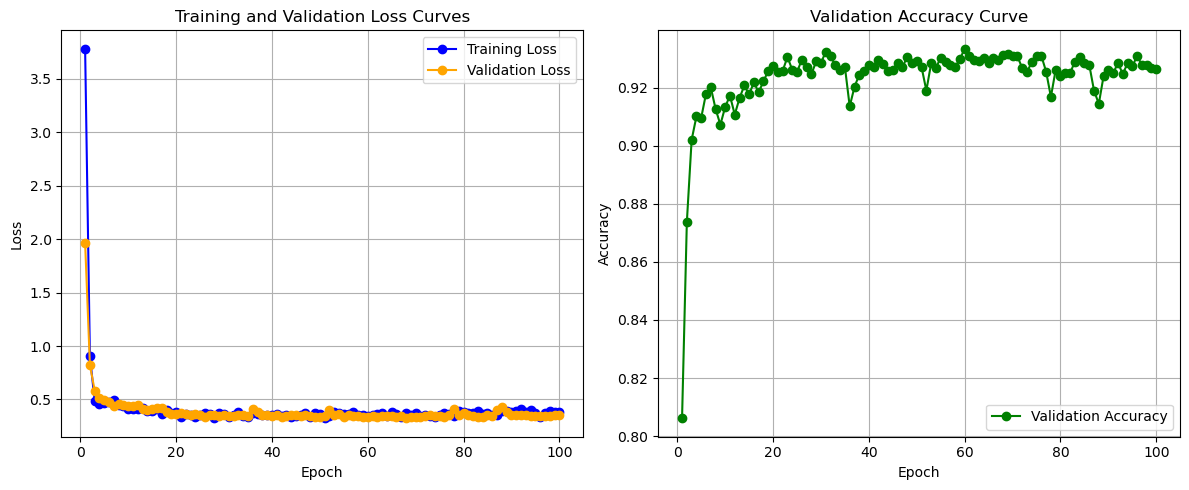

In [4]:
plot_loss_curves()